In [2]:
from typing import List,TypedDict
import re

import pypdf
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS

from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAIEmbeddings
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START,END
from pydantic import BaseModel
from dotenv import load_dotenv

from langchain_community.tools.tavily_search import TavilySearchResults

load_dotenv()

True

### Load the documents

In [ ]:
docs = (
    PyPDFLoader("documents/oops.pdf").load()
)

### Chunk Creation

In [4]:
chunks = RecursiveCharacterTextSplitter(chunk_size=600,chunk_overlap=100).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode('utf-8','ignore').decode('utf-8','ignore')

In [5]:
len(chunks)

62

### Embeddings

In [6]:
embeddings = GoogleGenerativeAIEmbeddings(model='gemini-embedding-001')
vector_stores = FAISS.from_documents(chunks,embeddings)

### Retriever

In [7]:
retriever = vector_stores.as_retriever(search_type='similarity',search_kwargs={"k":1})

### LLM

In [8]:
llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

### Threshold

In [9]:
UPPER_TH = 0.7
LOWER_TH = 0.3

## State

In [10]:
class State(TypedDict):

    question : str
    docs : List[Document]

    good_docs : List[Document]
    verdict : str
    reason : str

    strips : List[str]
    kept_strips : List[str]

    refined_context : str

    web_docs : List[Document]

    web_query: str

    answer : str

## Graph Nodes

#### Retriever Node

In [11]:
def retriever_node(state: State):
    question = state['question']
    return {'docs': retriever.invoke(question)}

### Score Based Doc Eval

In [ ]:
class DocEvalScore(BaseModel):
    score : int
    reason : str

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',   
            "You evaluate RAG retrieval.\n"
            "Given a question and ONE chunk, return relevance score [0–1].\n"
            "1 = sufficient to answer, 0 = irrelevant.\n"
            "Be conservative.\n"
            "Return JSON:"
        ),
        ("human", "Question: {question}\n\nchunk: {chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

def eval_each_doc_node(state: State):

    q = state['question']

    scores : List[float] = []
    reasons : List[str] = []
    good : List[Document] = []

    for d in state['docs']:

        out = doc_eval_chain.invoke({'question':q,"chunk": d.page_content}) 

        scores.append(out.score)
        reasons.append(out.reason)

        if out.score > LOWER_TH:

            good.append(d)

    
    # Correct
    if any(s > UPPER_TH for s in scores):
        return {
            'verdict': "CORRECT",
            'good_docs': good,
            "reason": "At least on doc greater than Upper threshold"
        }
    
    # incorrect
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        return {
            'good_docs': [],
            'verdict': "INCORRECT",
            'reason': "No one scores greater than lower threshold"
        }
    
    # aAmbiguous

    return{
        'good_docs': good,
        'verdict': "AMBIGUOUS",
        'reason': f"Mixed Ambiguous"
    }



### Knowledge Refinement

In [ ]:
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


class KeepOrNot(BaseModel):
    keep : bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Decide if a sentence helps answer the question. Return JSON"
        ),
        ("human", "Q:{question}\nS:{sentence}")
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrNot)

def refine(state: State):

    if state.get('verdict')  == "CORRECT":
        docs_to_use = state['good_docs']
    elif state.get('verdict') == "INCORRECT":
        docs_to_use = state['web_docs']
    else:
        docs_to_use = state['good_docs'] + state['web_docs']

    context = "\n\n".join(d.page_content for d in docs_to_use).strip()

    strips = decompose_to_sentences(context)

    kept_strips : List[str] = []

    for i,s in enumerate(strips): # for least use of API 
        if i >= 4:
            break
        
        if filter_chain.invoke({'question':state['question'],'sentence':s}).keep:
            kept_strips.append(s)

    refined_context = "\n".join(kept_strips).strip()

    return {
        'strips': strips,
        'kept_strips': kept_strips,
        'refined_context': refined_context    
    }

## Web Search Node

### Here Query Rewrite for searching purpose and better searching

In [14]:
class WebQuery(BaseModel):

    query : str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the query in better way that efficient for searching Do not answer the query.\n"
        ),
        ("human","Question: {question}")
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)

def rewrite_query_node(state: State):
    out = rewrite_chain.invoke({'question':state['question']})
    return {'web_query':out.query }

In [15]:
tavily = TavilySearchResults(max_results=1)

def web_search_node(state: State):

    q = state['web_query'] or state['question']

    results = tavily.invoke({'query':q})


    web_docs = []

    for r in results or []:
        title = r.get('title',"")
        url = r.get('url',"")
        content = r.get('content',"") or r.get("snippet","")

        text = f"TITLE: {title} \n URL: {url} \n CONTENT: \n {content}"

        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title}))


    return {"web_docs": web_docs}


C:\Users\gandh\AppData\Local\Temp\ipykernel_11508\1009560836.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=1)


### Generate Answer

In [16]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are Helpful ML tutor. Answer only using the provided refined bullets.\n"
            "If the bullets are empty or insufficient say: I don't Know based on the provided book"
        ),
        (
            "human","Question: {question}\n\nRefined Context \n {refined_context}"
        )
    ]
)

def generate(state: State):

    q = state['question']
    content = state['refined_context']

    answer = (answer_prompt | llm).invoke({'question':q,'refined_context':content})

    return {'answer':answer.content}

In [17]:

def route_after_eval(state: State):

    if state['verdict'] == "CORRECT":
        return 'refine'
    else:
        return "rewrite_query"
    

## Graph Build

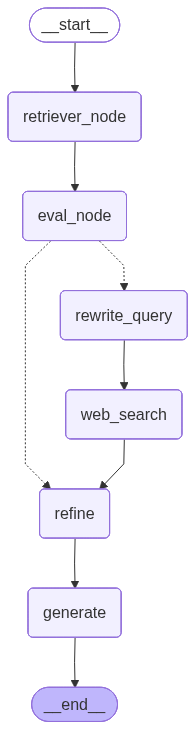

In [19]:
g = StateGraph(State)
g.add_node("retriever_node",retriever_node)
g.add_node('eval_node',eval_each_doc_node)
g.add_node('refine',refine)
g.add_node('web_search',web_search_node)
g.add_node("generate",generate)
g.add_node('rewrite_query',rewrite_query_node)


g.add_edge(START,"retriever_node")
g.add_edge('retriever_node','eval_node')
g.add_conditional_edges(
    'eval_node',
    route_after_eval,
    {'refine':'refine','rewrite_query':'rewrite_query'}
)

g.add_edge('rewrite_query','web_search')
g.add_edge('web_search','refine')
g.add_edge('refine','generate')

g.add_edge('generate',END)

app = g.compile()

app

In [30]:
res = app.invoke({"question": "What is object oriented programing  with latest update in cpp related to object oriented"})

In [31]:
print("VERDICT:",res['verdict'])

VERDICT: INCORRECT


In [32]:
print(res["answer"])

I don't Know based on the provided book


In [33]:
print(res['web_docs'])

[Document(metadata={'url': 'https://www.geeksforgeeks.org/cpp/object-oriented-programming-in-cpp/', 'title': 'Object Oriented Programming in C++ - GeeksforGeeks'}, page_content='TITLE: Object Oriented Programming in C++ - GeeksforGeeks \n URL: https://www.geeksforgeeks.org/cpp/object-oriented-programming-in-cpp/ \n CONTENT: \n geeksforgeeks\n\n# Object Oriented Programming in C++\n\nBefore Object-Oriented Programming (OOPs), most programs used a procedural approach, where the focus was on writing step-by-step functions. This made it harder to manage and reuse code in large applications.\n\nOOP in C++ was introduced to solve this problem by organizing code into classes and objects, making programs easier to understand, reuse, and maintain.\n\nTypes_of_OOPS\n\n## Class\n\nA class is a user-defined blueprint or prototype from which objects are created. It represents the set of properties or methods that are common to all objects of one type. Using classes, you can create multiple objects 

In [34]:
print(res['web_query'])

object oriented programming C++ latest updates
